# Zepto E-Commarce product Analysis - 

In [2]:
import numpy as np # For mathametical operation
import pandas as pd # For Dataframe
import matplotlib.pyplot as plt # For Visualization
import seaborn as sns 

In [3]:
df = pd.read_csv('zepto_v2.csv', lineterminator = '\n')

In [4]:
df.head()

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity\r
0,Fruits & Vegetables,Onion,2500,16,3,2100,1000,False,1
1,Fruits & Vegetables,Tomato Hybrid,4200,16,3,3500,1000,False,1
2,Fruits & Vegetables,Tender Coconut,5100,15,3,4300,58,False,1
3,Fruits & Vegetables,Coriander Leaves,2000,15,3,1700,100,False,100
4,Fruits & Vegetables,Ladies Finger,1400,14,3,1200,250,False,250


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3732 entries, 0 to 3731
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Category                3732 non-null   str  
 1   name                    3732 non-null   str  
 2   mrp                     3732 non-null   int64
 3   discountPercent         3732 non-null   int64
 4   availableQuantity       3732 non-null   int64
 5   discountedSellingPrice  3732 non-null   int64
 6   weightInGms             3732 non-null   int64
 7   outOfStock              3732 non-null   bool 
               3732 non-null   int64
dtypes: bool(1), int64(6), str(2)
memory usage: 237.0 KB


# Dataset Infromation 

In [6]:
df.shape

(3732, 9)

In [8]:
df.columns

Index(['Category', 'name', 'mrp', 'discountPercent', 'availableQuantity',
       'discountedSellingPrice', 'weightInGms', 'outOfStock', 'quantity\r'],
      dtype='str')

In [9]:
df.describe()

,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,quantity\r
count,3732.000000,3732.000000,3732.000000,3732.000000,3732.000000,3732.000000
mean,15680.117899,7.617095,4.008574,14192.834941,387.843783,213.270900
std,16088.807618,9.211733,2.203511,13850.726265,678.096509,194.730976
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6000.000000,0.000000,2.000000,5500.000000,100.000000,50.000000
50%,11000.000000,6.000000,5.000000,10400.000000,225.000000,186.000000
75%,20000.000000,10.000000,6.000000,18400.000000,450.000000,340.000000
max,260000.000000,51.000000,6.000000,139900.000000,10000.000000,1500.000000


In [10]:
df.isnull().sum()

Category                  0
name                      0
mrp                       0
discountPercent           0
availableQuantity         0
discountedSellingPrice    0
weightInGms               0
outOfStock                0
quantity\r                0
dtype: int64

In [11]:
df.nunique()

Category                    14
name                      1681
mrp                        266
discountPercent             42
availableQuantity            7
discountedSellingPrice     350
weightInGms                158
outOfStock                   2
quantity\r                 143
dtype: int64

# Data Duplicates

- Remove Duplicates


In [14]:
df = df.drop_duplicates()
df.head()

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity\r
0,Fruits & Vegetables,Onion,2500,16,3,2100,1000,False,1
1,Fruits & Vegetables,Tomato Hybrid,4200,16,3,3500,1000,False,1
2,Fruits & Vegetables,Tender Coconut,5100,15,3,4300,58,False,1
3,Fruits & Vegetables,Coriander Leaves,2000,15,3,1700,100,False,100
4,Fruits & Vegetables,Ladies Finger,1400,14,3,1200,250,False,250


- Check Missing Values

In [16]:
df.isnull().sum()

Category                  0
name                      0
mrp                       0
discountPercent           0
availableQuantity         0
discountedSellingPrice    0
weightInGms               0
outOfStock                0
quantity\r                0
dtype: int64

# Convert Prices into Rupees

In [17]:
df["mrp"] = df["mrp"] / 100

df["discountedSellingPrice"] = df["discountedSellingPrice"] / 100

df.head()

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity\r
0,Fruits & Vegetables,Onion,25.0,16,3,21.0,1000,False,1
1,Fruits & Vegetables,Tomato Hybrid,42.0,16,3,35.0,1000,False,1
2,Fruits & Vegetables,Tender Coconut,51.0,15,3,43.0,58,False,1
3,Fruits & Vegetables,Coriander Leaves,20.0,15,3,17.0,100,False,100
4,Fruits & Vegetables,Ladies Finger,14.0,14,3,12.0,250,False,250


# Bussinuess Question 

# Q1 Which Categories have the highest number of product ?

In [20]:
category_count = df["Category"].value_counts()

category_count

Category
Cooking Essentials       514
Munchies                 514
Packaged Food            388
Ice Cream & Desserts     388
Chocolates & Candies     388
Personal Care            343
Paan Corner              343
Home & Cleaning          194
Biscuits                 147
Dairy, Bread & Batter    129
Beverages                129
Health & Hygiene          97
Fruits & Vegetables       93
Meats, Fish & Eggs        63
Name: count, dtype: int64

# Visualization

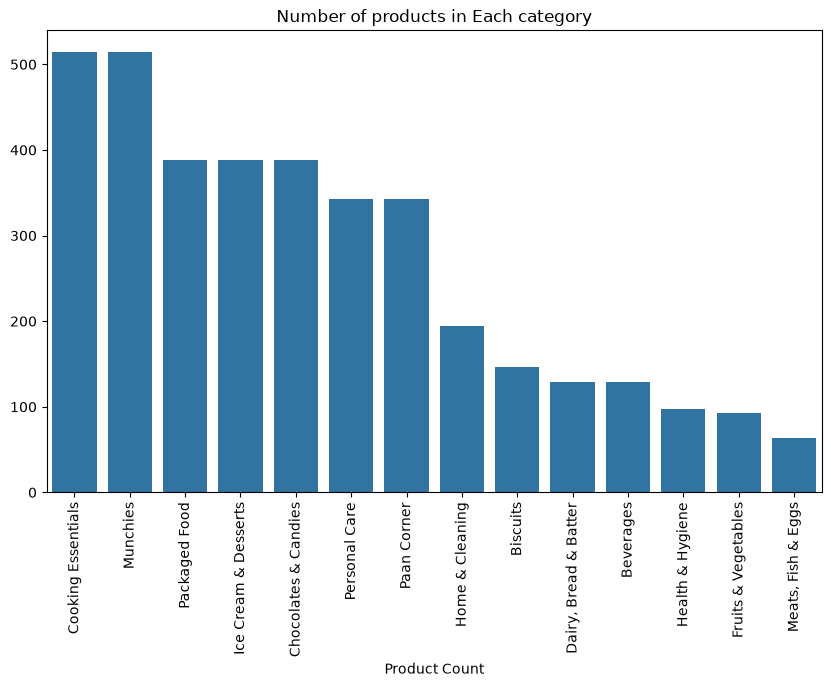

In [23]:
plt.figure(figsize=(10,6))

sns.barplot(x=category_count.index,
            y=category_count.values)

plt.xticks(rotation=90)
plt.title("Number of products in Each category")

plt.xlabel("Category")
plt.xlabel("Product Count")

plt.show()

# Q2 Top 10 Most Expensive products


In [25]:
top_expensive = df.sort_values(by="mrp", ascending=False)

top_expensive[["name", "Category","mrp"]].head(10)

,name,Category,mrp
1031,Borges Extra Light Olive Oil Bottle,Munchies,2600.0
517,Borges Extra Light Olive Oil Bottle,Cooking Essentials,2600.0
3016,Pampers Pants - Large,Personal Care,1549.0
3360,Pampers Pants - Large,Paan Corner,1549.0
877,Praakritik Natural Desi Gir Cow A2 Ghee,Munchies,1450.0
363,Praakritik Natural Desi Gir Cow A2 Ghee,Cooking Essentials,1450.0
121,Dhara Kachi Ghani Mustard Oil Jar,Cooking Essentials,1250.0
635,Dhara Kachi Ghani Mustard Oil Jar,Munchies,1250.0
144,Saffola Gold (Jar),Cooking Essentials,1240.0
658,Saffola Gold (Jar),Munchies,1240.0


# Visualization


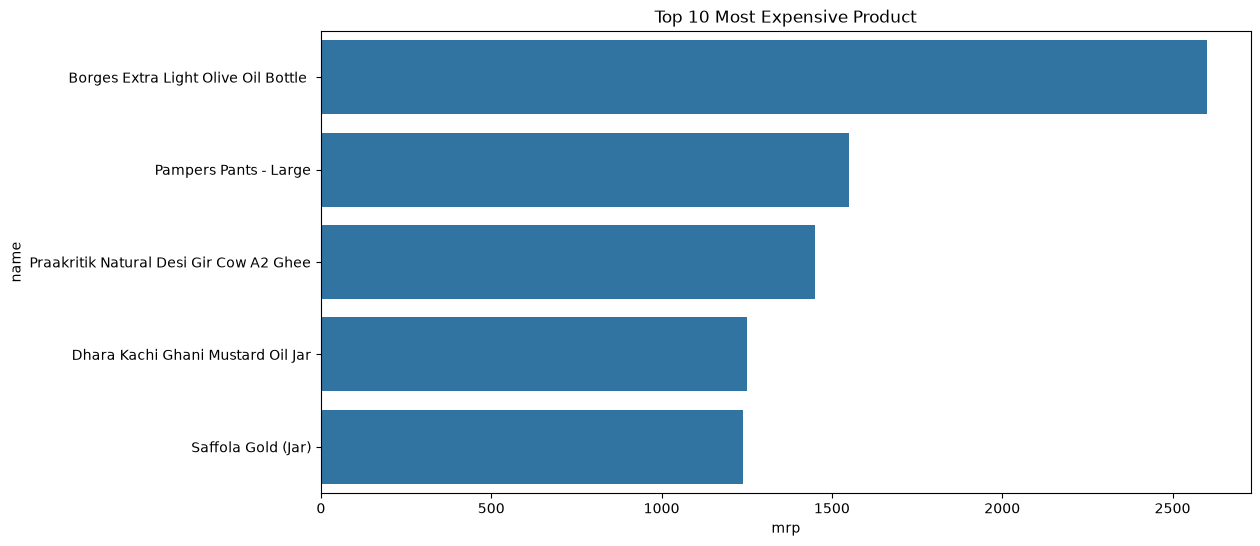

In [26]:
plt.figure(figsize=(12,6))

sns.barplot(data=top_expensive.head(10),
            x="mrp",
            y="name")
plt.title("Top 10 Most Expensive Product")

plt.show()
        

# Q3 Which Category gives Highest Average Discount ?

In [31]:
avg_discount = df.groupby("Category")["discountPercent"].mean().sort_values(ascending=False)

avg_discount

Category
Fruits & Vegetables      15.462366
Meats, Fish & Eggs       11.031746
Ice Cream & Desserts      8.324742
Packaged Food             8.324742
Chocolates & Candies      8.324742
Biscuits                  8.244898
Health & Hygiene          8.051546
Munchies                  7.163424
Cooking Essentials        7.163424
Beverages                 7.155039
Dairy, Bread & Batter     7.155039
Paan Corner               6.239067
Personal Care             6.239067
Home & Cleaning           5.675258
Name: discountPercent, dtype: float64

# Visualization 

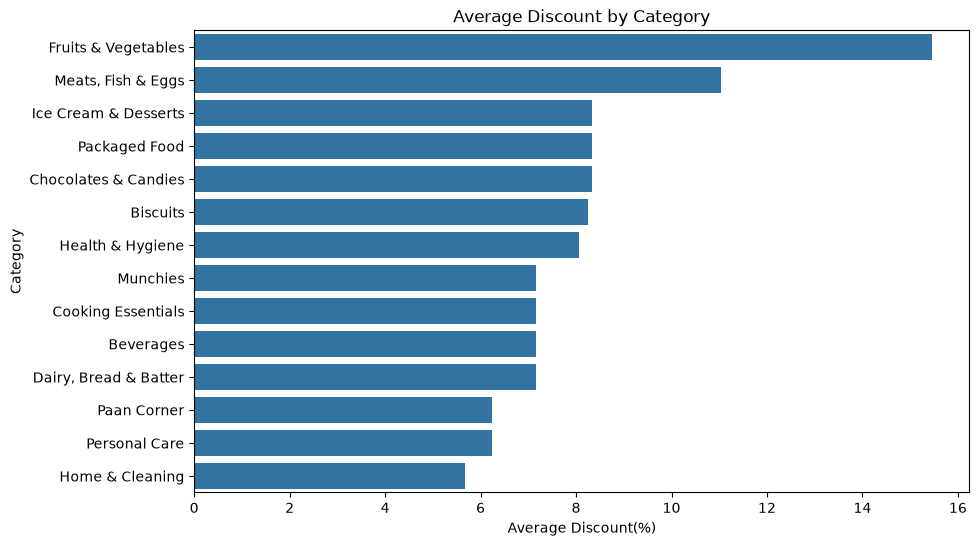

In [33]:
plt.figure(figsize=(10,6))

sns.barplot(x=avg_discount.values,
            y=avg_discount.index)

plt.title("Average Discount by Category")

plt.xlabel("Average Discount(%)")
plt.ylabel("Category")

plt.show()



# Q4 Top 10 Products with Highest Discount ?

In [36]:
highest_discount = df.sort_values(by="discountPercent", ascending=False)

highest_discount[["name","discountPercent"]].head(10)

,name,discountPercent
2619,Dukes Waffy Strawberry Wafers,51
2615,Dukes Waffy Orange Wafers,51
2608,Dukes Waffy Chocolate Wafers,51
1174,RRO Sour Cream,50
792,Ceres Foods Fish Mustard Instant Liquid Masala,50
909,Ceres Foods Laal Maas Instant Liquid Masala,50
1107,Chef's Basket Durum Wheat Penne Pasta,50
712,Chef's Basket Durum Wheat Elbow Pasta,50
1342,RRO Mascarpone Cheese,50
1329,RRO Burrata Cheese,50


# Q5 Out of stock vs Available Product

In [40]:
stock = df["outOfStock"].value_counts()

stock

outOfStock
False    3277
True      453
Name: count, dtype: int64

# Extra Analysis 

- Distribution of Product Price

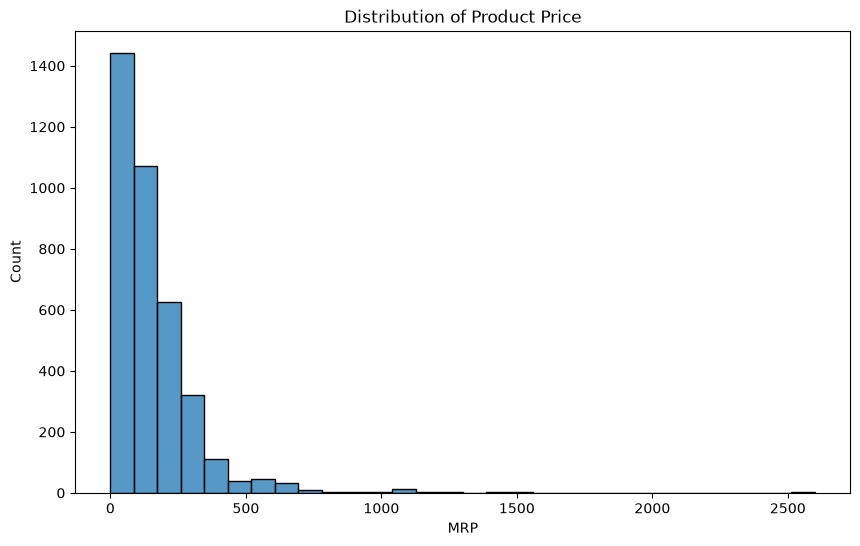

In [42]:
plt.figure(figsize=(10,6))

sns.histplot(df["mrp"], bins=30)

plt.title("Distribution of Product Price")

plt.xlabel("MRP")

plt.show()

# Correlation Heatmap

) missing from font(s) DejaVu Sans.s\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 13 (
  fig.canvas.draw()
) missing from font(s) DejaVu Sans.s\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


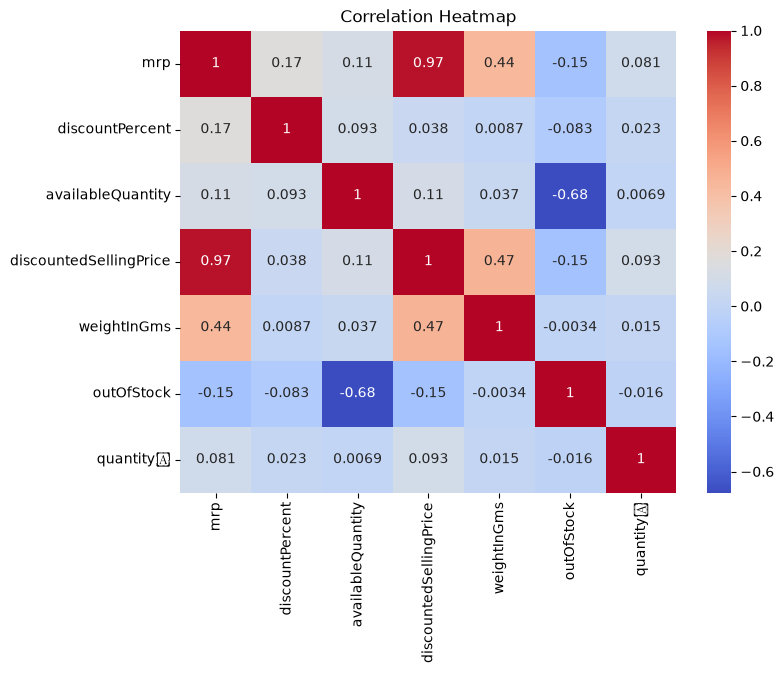

In [45]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),

           annot=True,
           cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()
           



** Final Conclusion **
- Q1 What Categories have the highest number of product?
- This graph shows which product category has the highest number of product of products available on Zepto.
- Q2 Top 10 Expensive Products.
- This analysis helps identitfy premium products with the highest Maximum Retail Price(MRP)
- Q3 What Category gives Highest Average Discount?
- This graph shows which product category provides the highest average discount to customers.
- Q4 Top 10 Projects with Highest Discount.
- This identites products offering the biggest discounts.
- Q5 Out of stock vs Available Products.
- This pie chat shows the percentage of products currently available and out of stock.